# Load-profile clustering and PCA — segmenting customers by the *shape* of their day

Retailers segment meters by how they use energy across the day: evening-peak households,
daytime businesses, solar exporters. Unsupervised methods (KMeans, PCA) on half-hourly
profiles are the standard first pass, and they are also a rich source of interview
questions ("why did you scale that way?", "how did you pick k?", "is the split honest?").

**What's in here**
- building the meter-day × 48 matrix from UK settlement data (with a compact clean)
- shape vs size: normalising each day by its total
- KMeans: choosing k (inertia, silhouette), centroids, composition, stability, `n_init`
- PCA: explained variance, components as shapes, scores, reconstruction error
- PCA scores as features for a classifier, and why the split must be **grouped by meter**
- clustering the 20 meters themselves (agglomerative, euclidean vs cosine)
- using clusters: assigning new days, a cluster-based forecasting baseline
- caveats and a checklist

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

raw = pd.read_csv("../data/meter_halfhourly_2023.csv.gz")
meters = pd.read_csv("../data/meters.csv")
raw.shape, raw.columns.tolist()

((349439, 4), ['meter_id', 'settlement_date', 'settlement_period', 'kwh'])

## 1. A compact clean

The settlement file has planted faults (duplicates, one meter in Wh for a month, a stuck
week, a missing fortnight, DST days with 46/50 periods). The full detection story is in
`05_time_series_research/05_anomaly_detection_data_quality`; here we just apply the fixes
we need for a clean matrix. Every clustering result inherits whatever you leave in.

**Pitfall:** the `settlement_date` is a *local* date. UTC timestamps come from localising
midnight in `Europe/London` first; adding `(period-1) × 30 min` to a naive date silently
mislabels seven months of the year.

In [2]:
df = raw.drop_duplicates().copy()
df["date"] = pd.to_datetime(df["settlement_date"])
df["utc"] = (df["date"].dt.tz_localize("Europe/London").dt.tz_convert("UTC")
             + pd.to_timedelta((df["settlement_period"] - 1) * 30, unit="min"))

# unit fault: a meter-month whose median is > 100x that meter's other months
mm = df.groupby(["meter_id", df["date"].dt.month])["kwh"].median().unstack()
ratio = mm.div(mm.median(axis=1), axis=0)
bad_units = ratio.stack()[ratio.stack() > 100]
print("meter-months with a x1000 problem:", bad_units.round(0).to_dict())
for (mid, month) in bad_units.index:
    m = (df["meter_id"] == mid) & (df["date"].dt.month == month)
    df.loc[m, "kwh"] = df.loc[m, "kwh"] / 1000

# stuck values: a meter-day with a single distinct value
per_day = df.groupby(["meter_id", "date"])["kwh"].agg(n="size", nunique="nunique", total="sum")
stuck_days = per_day[per_day["nunique"] <= 1]
print("stuck meter-days:", len(stuck_days), "->", stuck_days.reset_index()["meter_id"].unique())

# keep complete 48-period days only (drops the two DST days and any day with a gap)
keep = per_day[(per_day["n"] == 48) & (per_day["nunique"] > 1)].index
df = df.set_index(["meter_id", "date"]).loc[keep].reset_index()
print("rows kept:", len(df), "| meter-days:", len(keep), "of", len(per_day))

meter-months with a x1000 problem: {('M100007', 9): 744.0}
stuck meter-days: 7 -> ['M100003']


rows kept: 332016 | meter-days: 6917 of 7286


## 2. The meter-day × 48 matrix

One row per (meter, date), one column per settlement period. This is the object every
method below consumes. Two versions: raw kWh (**size** matters) and each row divided by
its gross daily energy, the L1 norm (**shape** only).

**Pitfall:** dividing by the *net* total breaks on solar days: net import can be near zero
or negative, and the "shape" explodes. Normalise by the sum of absolute values.

In [3]:
X_raw = df.pivot_table(index=["meter_id", "date"], columns="settlement_period", values="kwh")
X_raw.columns = [f"p{c:02d}" for c in X_raw.columns]
totals = X_raw.sum(axis=1)                       # net daily kWh (can be small for a solar exporter)
l1 = X_raw.abs().sum(axis=1)                     # gross energy moved: import + export
X_raw, totals, l1 = X_raw[l1 > 1], totals[l1 > 1], l1[l1 > 1]
X_shape = X_raw.div(l1, axis=0)                  # divide by the L1 norm, not the net total

info = (X_raw.index.to_frame(index=False)
          .merge(meters[["meter_id", "customer_type", "has_solar", "tariff"]], on="meter_id", how="left"))
info["is_weekend"] = info["date"].dt.dayofweek >= 5
info["season"] = np.where(info["date"].dt.month.isin([5, 6, 7, 8, 9]), "summer", "winter")
info.index = X_raw.index
print(X_raw.shape, "| |rows| sum to 1 after normalising:", np.allclose(X_shape.abs().sum(axis=1), 1))
X_shape.iloc[:3, [0, 14, 24, 36, 47]].round(3)

(6917, 48) | |rows| sum to 1 after normalising: True


p01    p15    p25    p37    p48
meter_id date                                         
M100000  2023-01-01  0.010  0.013  0.028  0.007  0.008
         2023-01-02  0.006  0.008  0.028  0.008  0.012
         2023-01-03  0.011  0.009  0.043  0.009  0.011

## 3. KMeans: size vs shape

KMeans minimises squared euclidean distance. On raw kWh the big meters (SMEs, ~7x a
household) sit far from everything else, so the clusters become "big / medium / small",
not "morning / evening / daytime".

**Interview check:** "You clustered without scaling — what did you actually cluster?"
Answer: daily volume. Normalise per row for shape, or standardise per column if you
want both.

In [4]:
from sklearn.cluster import KMeans

km_raw = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_raw)
km_shape = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_shape)

comp_raw = pd.crosstab(km_raw.labels_, info["customer_type"])
comp_raw["mean_daily_kwh"] = totals.groupby(km_raw.labels_).mean().round(1)
print("raw kWh clusters -> split by SIZE:\n", comp_raw, "\n")
comp_shape = pd.crosstab(km_shape.labels_, [info["customer_type"], info["has_solar"]])
comp_shape["mean_daily_kwh"] = totals.groupby(km_shape.labels_).mean().round(1)
print("shape clusters -> by profile, sizes ignored (solar days get their own cluster):\n", comp_shape)

raw kWh clusters -> split by SIZE:
 customer_type  residential  sme  mean_daily_kwh
row_0                                          
0                        0  799            65.4
1                     5874   29             9.8
2                        0  215           123.2 

shape clusters -> by profile, sizes ignored (solar days get their own cluster):
 customer_type residential        sme mean_daily_kwh
has_solar           False True False               
row_0                                              
0                       0    0  1043           76.5
1                    5521  156     0           10.0
2                       0  197     0            0.0


## 4. Choosing k

Inertia always falls with k, so look for the elbow. Silhouette (mean over samples of
(b − a)/max(a, b)) peaks at a "natural" k but is O(n²): compute it on a subsample.

**Pitfall:** the elbow is a judgement call, and silhouette prefers well-separated blobs.
Here the silhouette is highest at k=2 (SME vs household, the dominant structure) and
stays flat to k=5; k=3 adds the solar-export days. On real portfolios load shapes are a
continuum, so expect modest silhouettes (0.2–0.4) even for a useful k.

In [5]:
from sklearn.metrics import silhouette_score

rng = np.random.default_rng(0)
sub = rng.choice(len(X_shape), 1500, replace=False)
rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=5, random_state=0).fit(X_shape)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X_shape.iloc[sub], km.labels_[sub])})
kt = pd.DataFrame(rows).set_index("k")
kt["inertia_drop_%"] = (-kt["inertia"].pct_change() * 100).round(1)
kt.round(3)

,inertia,silhouette,inertia_drop_%
k,,,
2,23.931,0.485,NaN
3,16.171,0.523,32.4
4,15.599,0.123,3.5
5,15.169,0.119,2.8
6,14.653,0.114,3.4
7,14.301,0.114,2.4
8,14.049,0.114,1.8


## 5. Centroids are the interpretation

Each centroid is a 48-value profile. Plot them against the local half-hour and name them.
A cluster you cannot name is a cluster you cannot use. Here: a daytime (SME) shape, an
evening-peak household shape, and a solar shape that goes negative at midday.

,peak_hour_local,evening_share_17_21,daytime_share_09_17,min_share
0,8.5,0.126,0.613,0.0082
1,18.5,0.281,0.283,0.0162
2,18.5,0.209,-0.460,-0.0484


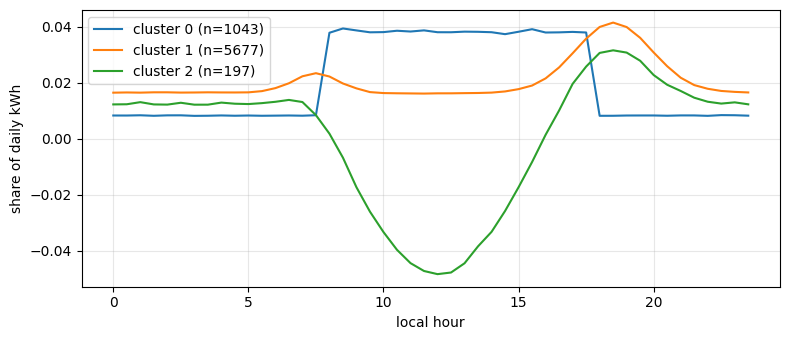

In [6]:
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X_shape)
labels = pd.Series(km.labels_, index=X_shape.index, name="cluster")
centroids = pd.DataFrame(km.cluster_centers_, columns=X_shape.columns)

hh = np.arange(48) / 2
fig, ax = plt.subplots(figsize=(8, 3.5))
for c in range(K):
    ax.plot(hh, centroids.iloc[c], label=f"cluster {c} (n={int((labels == c).sum())})")
ax.set_xlabel("local hour"); ax.set_ylabel("share of daily kWh"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()

peak_period = centroids.idxmax(axis=1)
pd.DataFrame({"peak_hour_local": [int(p[1:]) / 2 - 0.5 for p in peak_period],
              "evening_share_17_21": centroids.loc[:, "p35":"p42"].sum(axis=1).round(3),
              "daytime_share_09_17": centroids.loc[:, "p19":"p34"].sum(axis=1).round(3),
              "min_share": centroids.min(axis=1).round(4)})

## 6. Composition: what is in each cluster?

Cross-tabulate the labels against things you know (customer type, weekend, season, solar).
If a cluster is 95% SME weekdays, call it that. Row-normalise so you see shares.

In [7]:
ct = pd.concat([
    pd.crosstab(labels, info["customer_type"], normalize="index"),
    pd.crosstab(labels, info["is_weekend"], normalize="index").rename(columns={True: "weekend", False: "weekday"}),
    pd.crosstab(labels, info["season"], normalize="index"),
    pd.crosstab(labels, info["has_solar"], normalize="index").rename(columns={True: "solar"})[["solar"]],
], axis=1).round(2)
ct["n"] = labels.value_counts().sort_index()
ct

,residential,sme,weekday,weekend,summer,winter,solar,n
cluster,,,,,,,,
0,0.0,1.0,0.71,0.29,0.42,0.58,0.00,1043
1,1.0,0.0,0.72,0.28,0.41,0.59,0.03,5677
2,1.0,0.0,0.72,0.28,0.76,0.24,1.00,197


In [8]:
# Which meters live in which cluster? Meters spread across clusters day by day.
meter_mix = pd.crosstab(labels.index.get_level_values("meter_id"), labels, normalize="index").round(2)
meter_mix.join(meters.set_index("meter_id")[["customer_type", "has_solar"]]).sort_values("customer_type").head(8)

,0,1,2,customer_type,has_solar
row_0,,,,,
M100009,0.0,1.00,0.00,residential,False
M100017,0.0,1.00,0.00,residential,False
M100016,0.0,1.00,0.00,residential,False
M100014,0.0,1.00,0.00,residential,False
M100013,0.0,0.44,0.56,residential,True
M100012,0.0,1.00,0.00,residential,False
M100011,0.0,1.00,0.00,residential,False
M100018,0.0,1.00,0.00,residential,False


## 7. Stability and `n_init`

KMeans converges to a local optimum. `n_init` restarts and keeps the best inertia. Refit
with a different seed and compare labels with the adjusted Rand index (1 = identical
partition, 0 = random). Labels are arbitrary integers, so never compare `labels_a == labels_b`.
On well-separated data like this even `n_init=1` finds the same partition every time; the
label permutation is what bites (naive agreement 0.15 for an identical clustering).

**Interview check:** "Your cluster 2 became cluster 0 after a refit — is the model broken?"
No; label permutation is expected. Use ARI, or match clusters by centroid distance.

In [9]:
from sklearn.metrics import adjusted_rand_score

for n_init in [1, 10]:
    aris = []
    base = KMeans(n_clusters=K, n_init=n_init, random_state=0).fit(X_shape).labels_
    for seed in [1, 2, 3]:
        other = KMeans(n_clusters=K, n_init=n_init, random_state=seed).fit(X_shape).labels_
        aris.append(adjusted_rand_score(base, other))
    print(f"n_init={n_init:2d}: ARI vs seed 0 = {np.round(aris, 3)}  naive label agreement = {np.mean(base == other):.2f}")

n_init= 1: ARI vs seed 0 = [1. 1. 1.]  naive label agreement = 0.15


n_init=10: ARI vs seed 0 = [1. 1. 1.]  naive label agreement = 0.15


## 8. PCA: how many shapes are there really?

PCA finds orthogonal directions of maximal variance. On the shape matrix the first few
components are "the ways a day can differ from the average day". `explained_variance_ratio_`
tells you how many you need.

**Pitfall:** PCA is variance-driven, so on raw kWh the first component is just size again.
Centre (PCA does that) and think about scaling before you interpret components.

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=0).fit(X_shape)
evr = pd.Series(pca.explained_variance_ratio_, index=[f"PC{i+1}" for i in range(10)])
pd.DataFrame({"explained": evr.round(3), "cumulative": evr.cumsum().round(3)}).T

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
explained,0.493,0.111,0.025,0.023,0.022,0.020,0.017,0.016,0.013,0.012
cumulative,0.493,0.604,0.629,0.652,0.674,0.694,0.711,0.727,0.739,0.751


,morning_07_09,daytime_09_17,evening_17_21,night_00_06
PC1,0.18,3.43,-0.77,-0.48
PC2,0.33,1.51,1.74,1.03
PC3,-0.04,0.00,-0.07,-0.09


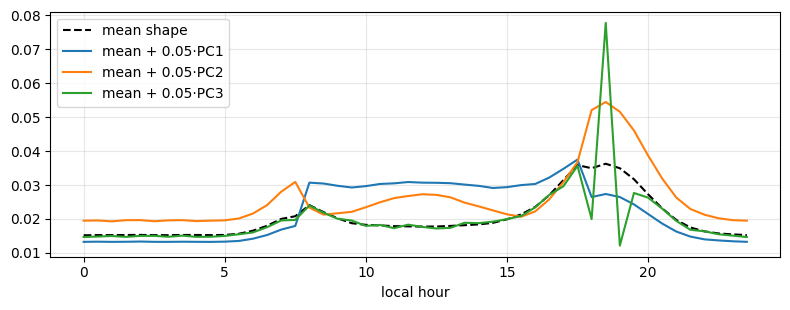

In [11]:
comps = pd.DataFrame(pca.components_[:3], index=["PC1", "PC2", "PC3"], columns=X_shape.columns)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(hh, pca.mean_, "k--", label="mean shape")
for i in range(3):
    ax.plot(hh, pca.mean_ + 0.05 * pca.components_[i], label=f"mean + 0.05·PC{i+1}")
ax.set_xlabel("local hour"); ax.legend(); ax.grid(alpha=.3); plt.tight_layout()

# where does each component load? (sign is arbitrary)
pd.DataFrame({"morning_07_09": comps.loc[:, "p15":"p18"].sum(axis=1),
              "daytime_09_17": comps.loc[:, "p19":"p34"].sum(axis=1),
              "evening_17_21": comps.loc[:, "p35":"p42"].sum(axis=1),
              "night_00_06": comps.loc[:, "p01":"p12"].sum(axis=1)}).round(2)

In [12]:
scores = pd.DataFrame(pca.transform(X_shape)[:, :3], index=X_shape.index, columns=["PC1", "PC2", "PC3"])
scores.join(info[["customer_type", "is_weekend", "has_solar"]]).groupby(["customer_type", "is_weekend"]).mean().round(3)

PC1    PC2  PC3  has_solar
customer_type is_weekend                              
residential   False      -0.018  0.005 -0.0       0.06
              True       -0.018  0.005 -0.0       0.06
sme           False       0.105 -0.031  0.0       0.00
              True        0.092 -0.028  0.0       0.00

### Reconstruction error

Project onto n components and back: the residual tells you what you threw away. It is
also a per-day anomaly score (a day that reconstructs badly is unusual).

In [13]:
rows = []
for n in [1, 2, 3, 5, 10, 20]:
    p = PCA(n_components=n, random_state=0).fit(X_shape)
    recon = p.inverse_transform(p.transform(X_shape))
    err = np.sqrt(((X_shape.values - recon) ** 2).mean(axis=1))
    rows.append({"n_components": n, "rmse_mean": err.mean(), "rmse_p99": np.quantile(err, 0.99)})
pd.DataFrame(rows).set_index("n_components").round(5)

,rmse_mean,rmse_p99
n_components,,
1,0.00725,0.01987
2,0.00661,0.00981
3,0.00639,0.00965
5,0.00598,0.00937
10,0.00520,0.00890
20,0.00412,0.00645


## 9. PCA scores as features — and an honest split

Predict the meter's **tariff** (Fixed vs other) from the first 5 PCA scores of a day's raw
kWh profile. Tariff has nothing to do with load shape in this data, so an honest model
should do no better than the majority rate. The catch: each meter contributes ~340 days
and each meter has its own size, so a shuffled split lets the classifier memorise
"a day of 12 kWh belongs to meter 9, which is on TOU". Use `GroupKFold(groups=meter_id)`
so every meter is entirely in train or entirely in test.

**Interview check:** "Shuffled CV beats the base rate, grouped CV does not — which one
tells you how it works on a new customer?" The grouped one. Same logic as time-series
splits: the unit of independence is the meter, not the row.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Xp = PCA(n_components=5, random_state=0).fit_transform(X_raw)
y = (info["tariff"].fillna("unknown") == "Fixed").astype(int).values
groups = X_shape.index.get_level_values("meter_id")
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

acc_shuffled = cross_val_score(clf, Xp, y, cv=KFold(5, shuffle=True, random_state=0))
acc_grouped = cross_val_score(clf, Xp, y, cv=GroupKFold(5), groups=groups)
print(f"base rate (always 'Fixed'): {y.mean():.3f}")
print(f"shuffled KFold accuracy : {acc_shuffled.mean():.3f}  folds {np.round(acc_shuffled, 3)}")
print(f"GroupKFold by meter     : {acc_grouped.mean():.3f}  folds {np.round(acc_grouped, 3)}")

base rate (always 'Fixed'): 0.601
shuffled KFold accuracy : 0.624  folds [0.63  0.613 0.651 0.617 0.611]
GroupKFold by meter     : 0.478  folds [0.387 0.603 0.651 0.497 0.251]


The shuffled score is above the base rate only because the model recognises meters; the
grouped score is *below* it, which is the honest answer: load shape does not predict
tariff. The grouped folds also vary a lot with just 4 meters per fold. That variance is
real; the shuffled number hides it.

## 10. Clustering the meters, not the days

Average each meter's shape over the year and cluster the 20 meters. With so few points,
hierarchical (agglomerative) clustering is easy to inspect. Distance matters: euclidean
on normalised shapes is fine; cosine ignores scale entirely and is a good choice when you
skipped the row-normalisation.

In [15]:
from sklearn.cluster import AgglomerativeClustering

meter_shape = X_shape.groupby(level="meter_id").mean()
meter_raw = X_raw.groupby(level="meter_id").mean()

agg_eu = AgglomerativeClustering(n_clusters=3, linkage="average").fit(meter_shape)
agg_cos_raw = AgglomerativeClustering(n_clusters=3, metric="cosine", linkage="average").fit(meter_raw)
agg_eu_raw = AgglomerativeClustering(n_clusters=3, linkage="average").fit(meter_raw)

out = meters.set_index("meter_id").loc[meter_shape.index, ["customer_type", "has_solar", "annual_kwh_estimate"]]
out["eucl_on_shape"] = agg_eu.labels_
out["cosine_on_raw"] = agg_cos_raw.labels_
out["eucl_on_raw"] = agg_eu_raw.labels_
out.sort_values(["customer_type", "eucl_on_shape"])

,customer_type,has_solar,annual_kwh_estimate,eucl_on_shape,cosine_on_raw,eucl_on_raw
meter_id,,,,,,
M100013,residential,True,2948.0,1,1,0
M100001,residential,False,2286.0,2,0,0
M100002,residential,False,3665.0,2,0,0
M100003,residential,False,2575.0,2,0,0
M100004,residential,False,2191.0,2,0,0
M100005,residential,False,3026.0,2,0,0
M100006,residential,False,4089.0,2,0,0
M100007,residential,False,3982.0,2,0,0
M100008,residential,False,3833.0,2,0,0


Euclidean on raw kWh isolates the three SMEs purely by size and lumps the solar meter with
households; cosine on raw and euclidean on shape both agree with the shape-based story.

## 11. Using clusters

- **Assign new days** with `predict` (nearest centroid). The model object, not the labels,
  is what you keep.
- **Cluster baseline forecast:** tomorrow's shape = centroid of today's cluster; scale by
  today's total. Compare with the naive "same as yesterday" per period.
- **Segment-level products:** a TOU tariff aimed at the evening-peak cluster, a solar
  export tariff for the exporters.

In [16]:
# December as a hold-out: fit KMeans on Jan-Nov shapes, forecast each December day from the previous day
dates = X_shape.index.get_level_values("date")
train_mask = dates < "2023-12-01"
km_tr = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X_shape[train_mask])
cent = km_tr.cluster_centers_

test_idx = X_raw.index[~train_mask]
mae_cluster, mae_naive, n = 0.0, 0.0, 0
for mid, d in test_idx:
    prev = (mid, d - pd.Timedelta(days=1))
    if prev not in X_raw.index:
        continue
    y_true = X_raw.loc[(mid, d)].values
    y_prev = X_raw.loc[prev].values
    c = km_tr.predict(X_shape.loc[[prev]])[0]
    y_cluster = cent[c] * y_prev.sum()          # yesterday's cluster shape x yesterday's volume
    mae_cluster += np.abs(y_true - y_cluster).mean()
    mae_naive += np.abs(y_true - y_prev).mean()
    n += 1
print(f"December, {n} meter-days | MAE per half-hour (kWh): cluster-centroid {mae_cluster/n:.4f} vs same-as-yesterday {mae_naive/n:.4f}")

December, 568 meter-days | MAE per half-hour (kWh): cluster-centroid 0.1372 vs same-as-yesterday 0.1864


The centroid baseline beats copying yesterday because it averages out the noise in a
single day while keeping the shape. It is still a baseline: a proper model would use the
cluster as a feature alongside lags and calendar.

## 12. Caveats to say aloud

- Cluster labels are not stable across refits (permutation, and boundary days move).
- k is a choice; report how results change with k.
- Clusters describe, they do not explain: an "evening-peak" cluster is not a cause.
- Normalisation decides what you cluster; say which you used and why.
- A day is not independent of the other days of the same meter: group your splits.
- Faults (stuck meters, unit errors) become their own clusters if you leave them in.

## Quick reference

| Task | Idiom |
|---|---|
| meter-day matrix | `pivot_table(index=[meter, date], columns=period, values=kwh)` |
| shape only | `X.div(X.sum(axis=1), axis=0)` |
| KMeans | `KMeans(k, n_init=10, random_state=0).fit(X)`; `.cluster_centers_`, `.labels_`, `.inertia_`, `.predict` |
| choose k | inertia elbow + `silhouette_score(X[sub], labels[sub])` |
| compare partitions | `adjusted_rand_score(a, b)` |
| PCA | `PCA(n).fit(X)`; `.explained_variance_ratio_`, `.components_`, `.transform`, `.inverse_transform` |
| honest CV over meters | `GroupKFold(5)` with `groups=meter_id` |
| few-point hierarchy | `AgglomerativeClustering(n, metric="cosine", linkage="average")` |